# Exploratory Data Analysis (EDA) and Machine Learning on Agricultural Yield Dataset

**Week 3 Assignment 1**

In [1]:
# Install / import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


---
## Part A: Understanding the Dataset

### Q1. Dataset Overview

In [2]:
# Upload the CSV file when prompted (in Colab: Files → Upload), or place it in the same directory
# from google.colab import files
# uploaded = files.upload()  # Uncomment in Colab to upload interactively

df = pd.read_csv('agriculture_yield_dataset.csv')

print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n=== Column Names ===')
print(df.columns.tolist())

print('\n=== First 10 Records ===')
df.head(10)

=== Dataset Shape ===
Rows: 1500, Columns: 8

=== Column Names ===
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

=== First 10 Records ===


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


### Q2. Data Types and Missing Values

In [3]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values per Column ===')
missing = df.isnull().sum()
print(missing)

print('\n=== Total Missing Values ===')
total_missing = missing.sum()
print(f'Total missing values: {total_missing}')

if total_missing > 0:
    print('\nAffected columns:')
    print(missing[missing > 0])
else:
    print('No missing values found in any column.')

=== Data Types ===
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

=== Missing Values per Column ===
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

=== Total Missing Values ===
Total missing values: 0
No missing values found in any column.


### Q3. Descriptive Statistics

In [4]:
print('=== Summary Statistics ===')
stats = df.describe()
display(stats)

# Feature with highest mean
highest_mean_feature = stats.loc['mean'].idxmax()
highest_mean_value = stats.loc['mean'].max()
print(f'\nFeature with highest mean: {highest_mean_feature} ({highest_mean_value:.2f})')

# Feature with highest standard deviation
highest_std_feature = stats.loc['std'].idxmax()
highest_std_value = stats.loc['std'].max()
print(f'Feature with highest standard deviation: {highest_std_feature} ({highest_std_value:.2f})')

=== Summary Statistics ===


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000



Feature with highest mean: rainfall_mm (754.05)
Feature with highest standard deviation: rainfall_mm (255.10)


---
## Part B: Exploratory Data Analysis (EDA)

### Q4. Distribution Analysis — Histograms

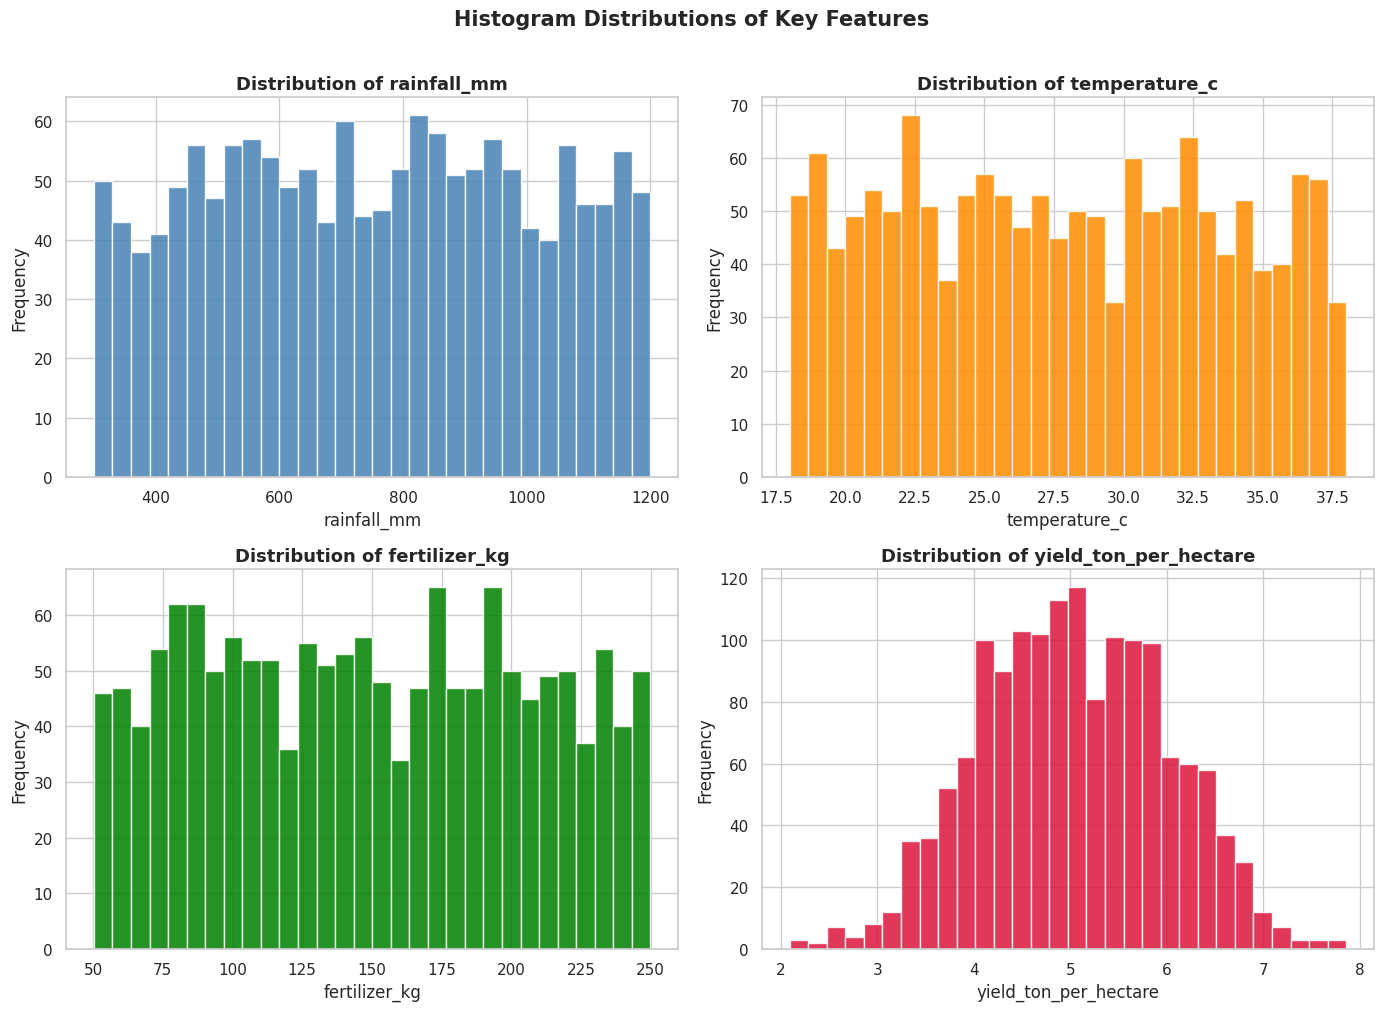


Observations:

rainfall_mm:
  1. The distribution is roughly uniform/spread across the range ~200–1200 mm.
  2. No strong peak suggests diverse rainfall conditions in the dataset.
  3. Slight right skew may be present with more records at lower rainfall values.

temperature_c:
  1. Temperature appears approximately normally distributed.
  2. Most values cluster between 15°C and 40°C.
  3. Very few extreme low or high temperature readings exist.

fertilizer_kg:
  1. Fertilizer usage appears roughly uniform across a wide range (~50–450 kg).
  2. No strong central tendency, suggesting varied farming practices.
  3. Higher bins are slightly less frequent, hinting at a mild left concentration.

yield_ton_per_hectare:
  1. Yield distribution looks approximately bell-shaped (normal).
  2. Most yields cluster between 3 and 8 tons/hectare.
  3. Tails are thin, suggesting few extreme yield outliers.



In [5]:
features_to_plot = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['steelblue', 'darkorange', 'green', 'crimson']

for i, (feat, color) in enumerate(zip(features_to_plot, colors)):
    axes[i].hist(df[feat], bins=30, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {feat}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histogram Distributions of Key Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("""
Observations:

rainfall_mm:
  1. The distribution is roughly uniform/spread across the range ~200–1200 mm.
  2. No strong peak suggests diverse rainfall conditions in the dataset.
  3. Slight right skew may be present with more records at lower rainfall values.

temperature_c:
  1. Temperature appears approximately normally distributed.
  2. Most values cluster between 15°C and 40°C.
  3. Very few extreme low or high temperature readings exist.

fertilizer_kg:
  1. Fertilizer usage appears roughly uniform across a wide range (~50–450 kg).
  2. No strong central tendency, suggesting varied farming practices.
  3. Higher bins are slightly less frequent, hinting at a mild left concentration.

yield_ton_per_hectare:
  1. Yield distribution looks approximately bell-shaped (normal).
  2. Most yields cluster between 3 and 8 tons/hectare.
  3. Tails are thin, suggesting few extreme yield outliers.
""")

### Q5. Crop Type Analysis

=== Records per Crop Type ===
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


/tmp/ipykernel_944/2952383145.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crop_type', palette='Set2', order=crop_counts.index)


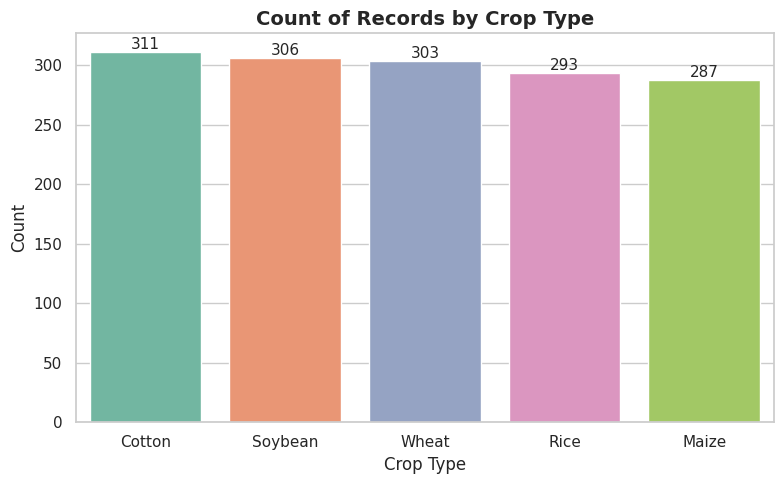


Most frequent crop type: Cotton (311 records)


In [6]:
print('=== Records per Crop Type ===')
crop_counts = df['crop_type'].value_counts()
print(crop_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='crop_type', palette='Set2', order=crop_counts.index)
plt.title('Count of Records by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

most_frequent_crop = crop_counts.idxmax()
print(f'\nMost frequent crop type: {most_frequent_crop} ({crop_counts.max()} records)')

### Q6. Soil Type Analysis

=== Frequency of Each Soil Type ===
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


/tmp/ipykernel_944/4175087564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='soil_type', palette='Set3', order=soil_counts.index)


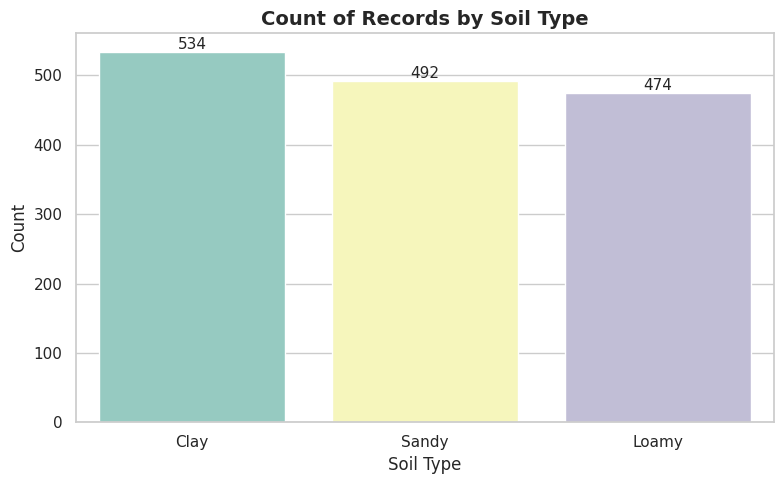


Most common soil type: Clay (534 records)


In [7]:
print('=== Frequency of Each Soil Type ===')
soil_counts = df['soil_type'].value_counts()
print(soil_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='soil_type', palette='Set3', order=soil_counts.index)
plt.title('Count of Records by Soil Type', fontsize=14, fontweight='bold')
plt.xlabel('Soil Type')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

most_common_soil = soil_counts.idxmax()
print(f'\nMost common soil type: {most_common_soil} ({soil_counts.max()} records)')

### Q7. Yield Distribution

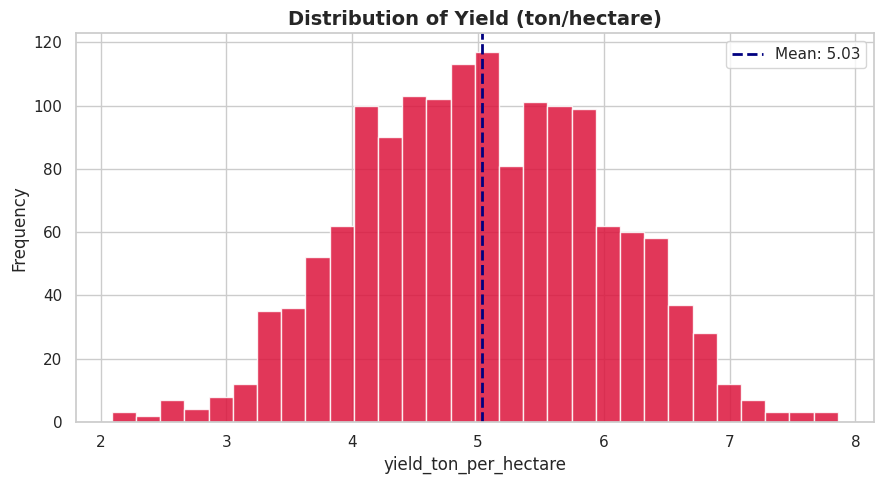

Skewness: -0.001

Observations:
- The distribution is approximately normal (bell-shaped) with slight skew.
- Skewness of -0.001 confirms the distribution is close to symmetric.
- No major outliers are immediately visible; values are concentrated between 2 and 9 tons/hectare.


In [8]:
plt.figure(figsize=(9, 5))
plt.hist(df['yield_ton_per_hectare'], bins=30, color='crimson', edgecolor='white', alpha=0.85)
plt.axvline(df['yield_ton_per_hectare'].mean(), color='navy', linestyle='--', linewidth=2, label=f"Mean: {df['yield_ton_per_hectare'].mean():.2f}")
plt.title('Distribution of Yield (ton/hectare)', fontsize=14, fontweight='bold')
plt.xlabel('yield_ton_per_hectare')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

skewness = df['yield_ton_per_hectare'].skew()
print(f'Skewness: {skewness:.3f}')
print('\nObservations:')
print('- The distribution is approximately normal (bell-shaped) with slight skew.')
print(f'- Skewness of {skewness:.3f} confirms the distribution is close to symmetric.')
print('- No major outliers are immediately visible; values are concentrated between 2 and 9 tons/hectare.')

### Q8. Scatter Plot Analysis

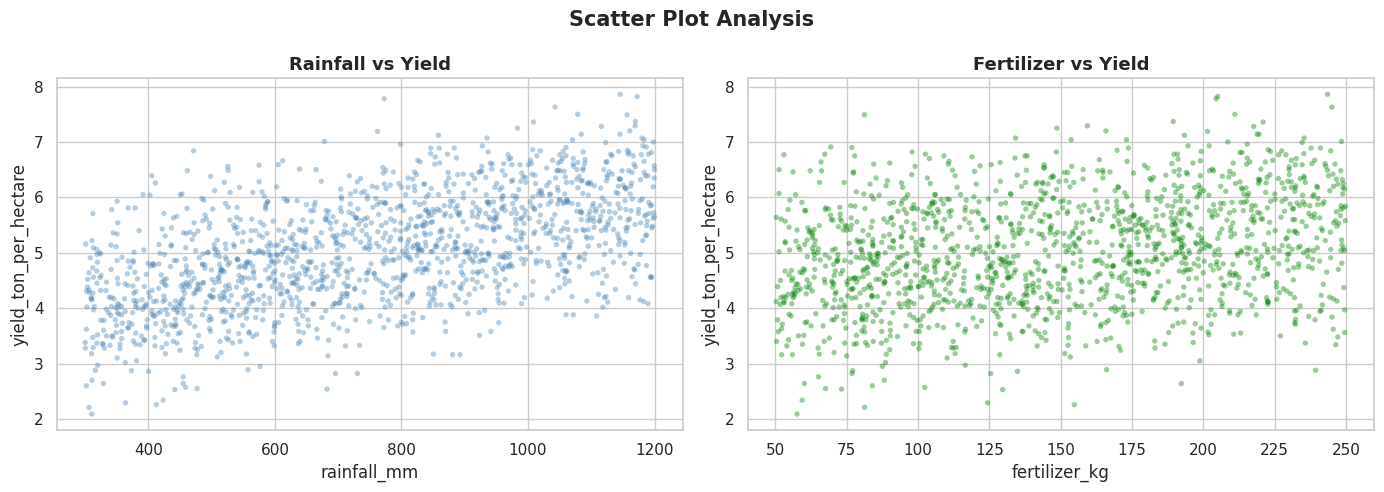

Correlation — rainfall_mm vs yield: 0.5537
Correlation — fertilizer_kg vs yield: 0.2780

Stronger relationship with yield: rainfall_mm


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['rainfall_mm'], df['yield_ton_per_hectare'], alpha=0.4, color='steelblue', edgecolors='none', s=15)
axes[0].set_title('Rainfall vs Yield', fontsize=13, fontweight='bold')
axes[0].set_xlabel('rainfall_mm')
axes[0].set_ylabel('yield_ton_per_hectare')

axes[1].scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'], alpha=0.4, color='green', edgecolors='none', s=15)
axes[1].set_title('Fertilizer vs Yield', fontsize=13, fontweight='bold')
axes[1].set_xlabel('fertilizer_kg')
axes[1].set_ylabel('yield_ton_per_hectare')

plt.suptitle('Scatter Plot Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

corr_rain = df['rainfall_mm'].corr(df['yield_ton_per_hectare'])
corr_fert = df['fertilizer_kg'].corr(df['yield_ton_per_hectare'])
print(f'Correlation — rainfall_mm vs yield: {corr_rain:.4f}')
print(f'Correlation — fertilizer_kg vs yield: {corr_fert:.4f}')
stronger = 'rainfall_mm' if abs(corr_rain) > abs(corr_fert) else 'fertilizer_kg'
print(f'\nStronger relationship with yield: {stronger}')

### Q9. Correlation Analysis

=== Correlation Matrix ===


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
rainfall_mm,1.000000,0.026721,0.002558,0.010877,0.006916,0.553704
temperature_c,0.026721,1.000000,0.037468,0.007114,0.001513,-0.022559
fertilizer_kg,0.002558,0.037468,1.000000,-0.010497,0.010001,0.278043
irrigation_hours,0.010877,0.007114,-0.010497,1.000000,0.009307,0.542664
soil_ph,0.006916,0.001513,0.010001,0.009307,1.000000,0.024412
yield_ton_per_hectare,0.553704,-0.022559,0.278043,0.542664,0.024412,1.000000


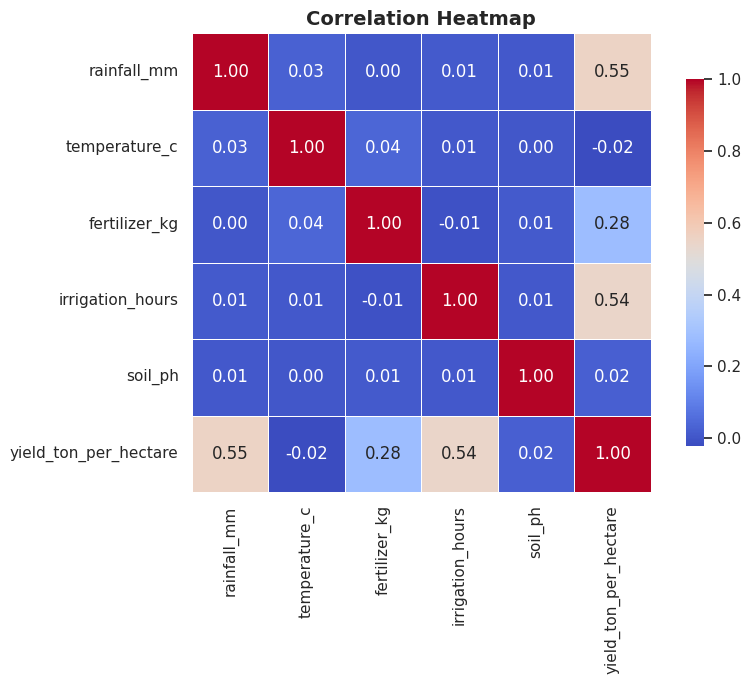


Top 3 features most correlated with yield_ton_per_hectare:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [10]:
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

print('=== Correlation Matrix ===')
display(corr_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 3 features correlated with yield
yield_corr = corr_matrix['yield_ton_per_hectare'].drop('yield_ton_per_hectare').abs().sort_values(ascending=False)
print('\nTop 3 features most correlated with yield_ton_per_hectare:')
print(yield_corr.head(3))

### Q10. Group-Based Analysis

=== Average Yield by Crop Type ===
crop_type
Rice       5.495
Soybean    5.173
Wheat      4.989
Maize      4.897
Cotton     4.607
Name: yield_ton_per_hectare, dtype: float64

=== Average Yield by Soil Type ===
soil_type
Loamy    5.367
Clay     5.134
Sandy    4.589
Name: yield_ton_per_hectare, dtype: float64


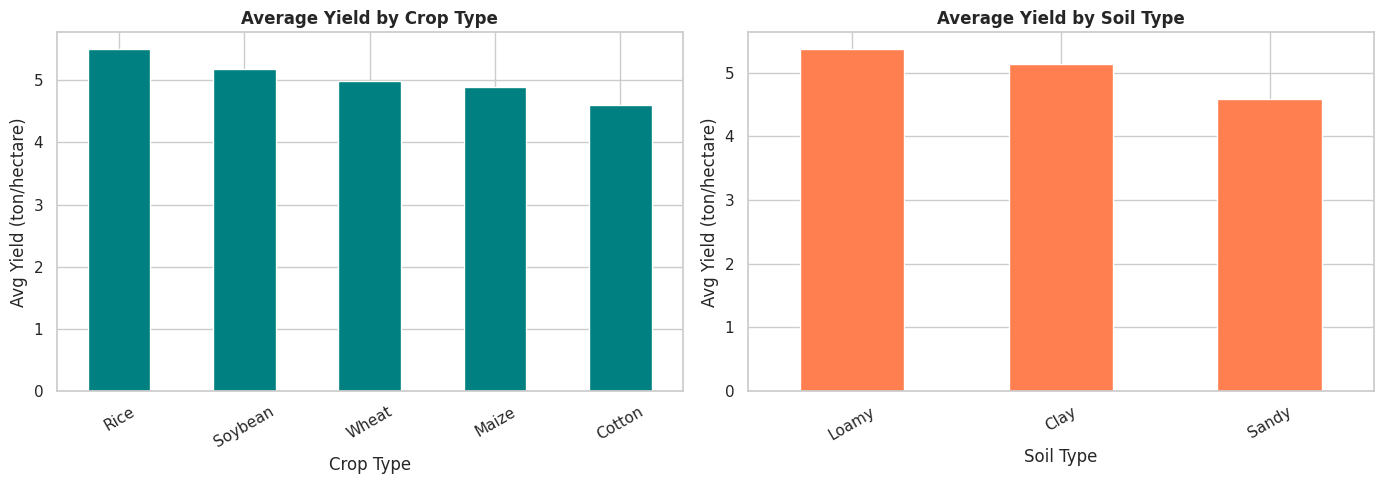


Crop type with highest average yield : Rice (5.495 ton/hectare)
Soil type with highest average yield  : Loamy (5.367 ton/hectare)


In [11]:
print('=== Average Yield by Crop Type ===')
avg_yield_crop = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print(avg_yield_crop.round(3))

print('\n=== Average Yield by Soil Type ===')
avg_yield_soil = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print(avg_yield_soil.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
avg_yield_crop.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Average Yield by Crop Type', fontweight='bold')
axes[0].set_xlabel('Crop Type')
axes[0].set_ylabel('Avg Yield (ton/hectare)')
axes[0].tick_params(axis='x', rotation=30)

avg_yield_soil.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Yield by Soil Type', fontweight='bold')
axes[1].set_xlabel('Soil Type')
axes[1].set_ylabel('Avg Yield (ton/hectare)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

best_crop = avg_yield_crop.idxmax()
best_soil = avg_yield_soil.idxmax()
print(f'\nCrop type with highest average yield : {best_crop} ({avg_yield_crop.max():.3f} ton/hectare)')
print(f'Soil type with highest average yield  : {best_soil} ({avg_yield_soil.max():.3f} ton/hectare)')

---
## Part C: Data Preparation

### Q11. Feature Encoding

In [12]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', categorical_cols)

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
print(f'\nShape after encoding: {df_encoded.shape}')
print('\nFirst 5 rows of transformed dataset:')
display(df_encoded.head())

print('\nNew columns after encoding:')
print([c for c in df_encoded.columns if c not in df.columns])

Categorical columns: ['crop_type', 'soil_type']

Shape after encoding: (1500, 14)

First 5 rows of transformed dataset:


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False



New columns after encoding:
['crop_type_Cotton', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Clay', 'soil_type_Loamy', 'soil_type_Sandy']


### Q12. Feature Selection

In [13]:
target_column = 'yield_ton_per_hectare'

X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

print(f'Target variable (y): {target_column}')
print(f'\nInput features (X) — {X.shape[1]} features:')
print(X.columns.tolist())
print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')

Target variable (y): yield_ton_per_hectare

Input features (X) — 13 features:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Cotton', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Clay', 'soil_type_Loamy', 'soil_type_Sandy']

X shape: (1500, 13)
y shape: (1500,)


---
## Part D: Machine Learning

### Q13. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('=== Train-Test Split Results ===')
print(f'X_train shape : {X_train.shape}  (80% training)')
print(f'X_test shape  : {X_test.shape}   (20% testing)')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape  : {y_test.shape}')

=== Train-Test Split Results ===
X_train shape : (1200, 13)  (80% training)
X_test shape  : (300, 13)   (20% testing)
y_train shape : (1200,)
y_test shape  : (300,)


### Q14. Linear Regression Model

In [15]:
# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print(f'Model Intercept: {lr_model.intercept_:.4f}')
print('\n=== Model Coefficients (sorted) ===')
display(coef_df)

# Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'\nModel Performance on Test Set:')
print(f'  Mean Squared Error (MSE): {mse:.4f}')
print(f'  R² Score               : {r2:.4f}')

# Feature with highest positive coefficient
top_positive = coef_df[coef_df['Coefficient'] > 0].iloc[0]
print(f'\nFeature with highest positive coefficient: {top_positive["Feature"]} ({top_positive["Coefficient"]:.4f})')

Model Intercept: 1.9111

=== Model Coefficients (sorted) ===


,Feature,Coefficient
0,crop_type_Rice,0.477369
1,soil_type_Loamy,0.365627
2,irrigation_hours,0.198327
3,crop_type_Soybean,0.095096
4,soil_type_Clay,0.062653
5,fertilizer_kg,0.004978
6,soil_ph,0.004901
7,rainfall_mm,0.002035
8,temperature_c,-0.009175
9,crop_type_Wheat,-0.038149



Model Performance on Test Set:
  Mean Squared Error (MSE): 0.1267
  R² Score               : 0.8628

Feature with highest positive coefficient: crop_type_Rice (0.4774)


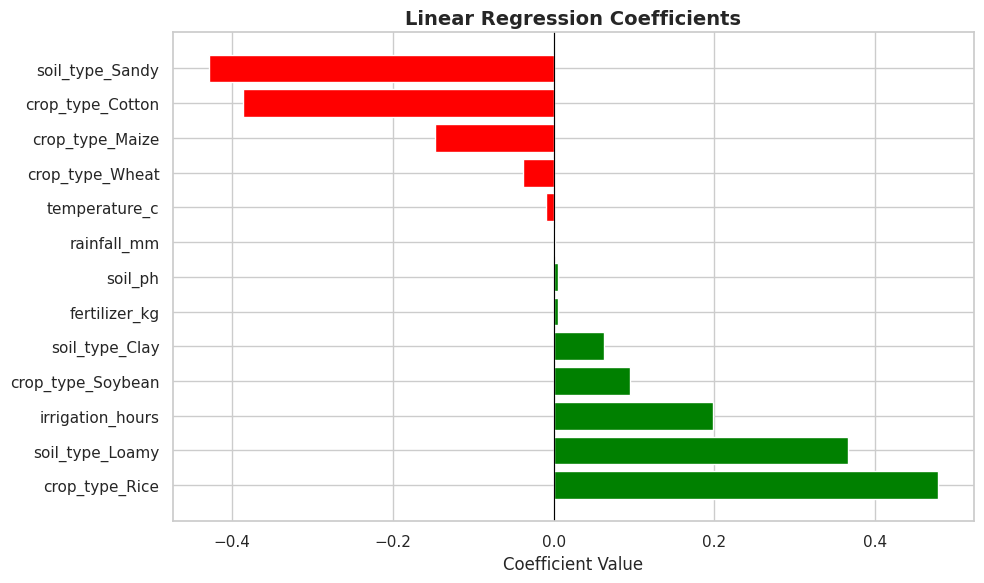

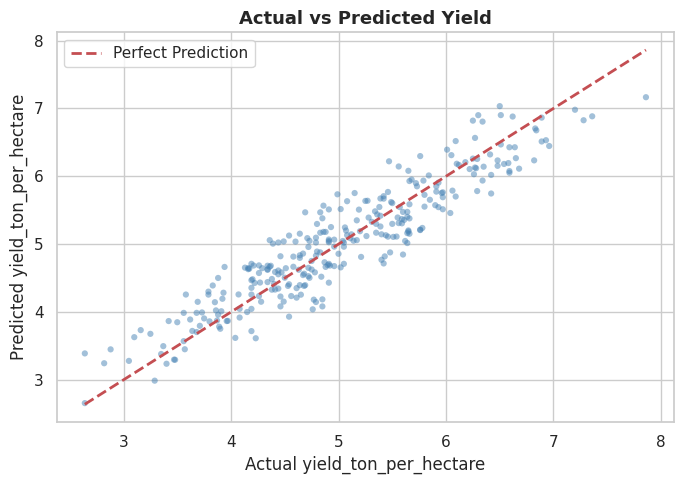

In [16]:
# Coefficient Bar Chart
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='none', s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Yield', fontsize=13, fontweight='bold')
plt.xlabel('Actual yield_ton_per_hectare')
plt.ylabel('Predicted yield_ton_per_hectare')
plt.legend()
plt.tight_layout()
plt.show()